d:\Machine_learning\Deeplearning\aiml_tutorials\CampusX-courses\mylang\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
d:\Machine_learning\Deeplearning\aiml_tutorials\CampusX-courses\mylang\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


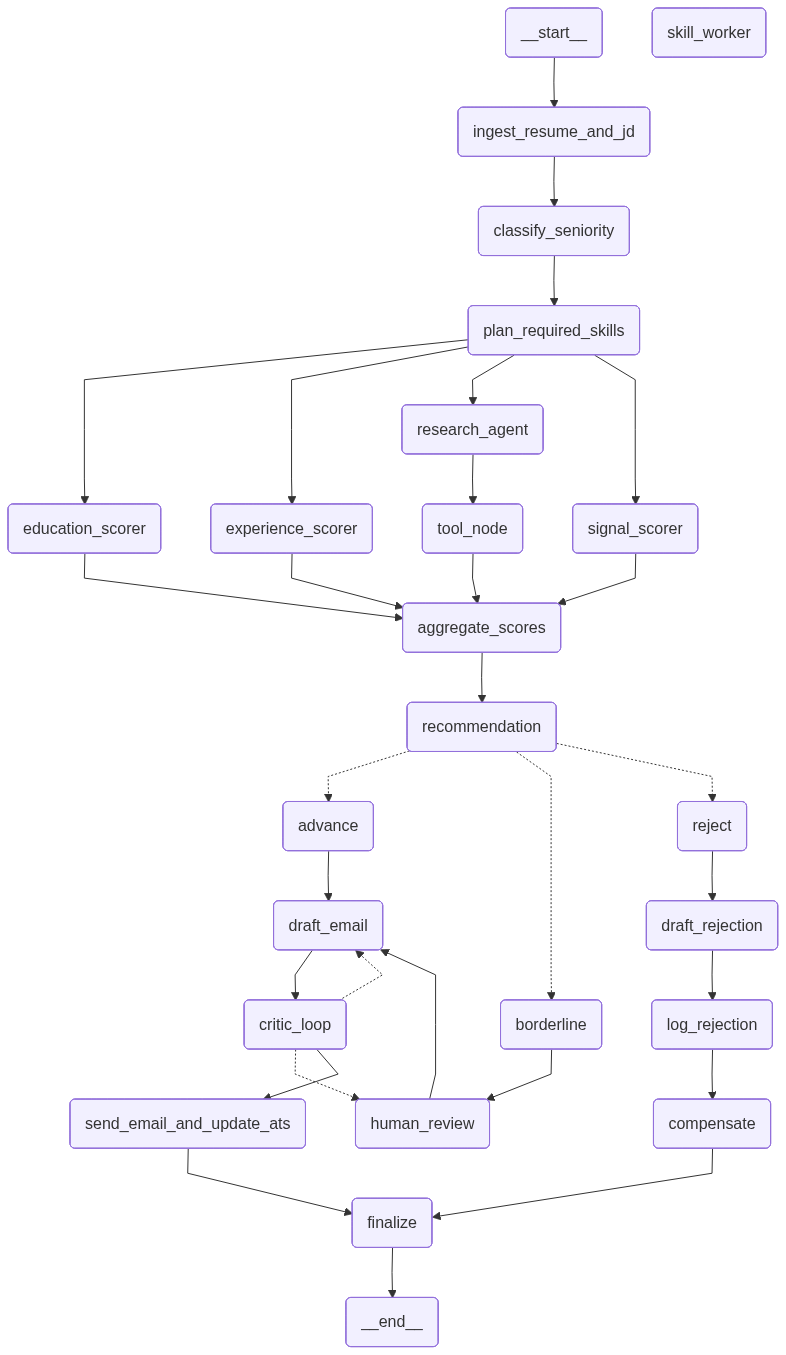

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[2]

sys.path.append(str(project_root))

from src.hiregraph.graph import build_graph

graph = build_graph()
graph

In [ ]:
from pathlib import Path
from langgraph.types import Command
from src.hiregraph.graph import build_graph

def load_file(path):
    return Path(path).read_text()


def test_graph_builds():
    graph = build_graph()

    assert graph is not None





    config = {
        "configurable": {
            "thread_id": "demo-1"
        }
    }

    # ---------------- INPUT DATA ----------------
    resume = load_file(r"D:\Machine_learning\Deeplearning\aiml_tutorials\azure_ai\python_rag\agentbuildercourse_satvik\hire_graph\sample_data\resumes\resume_priya.md")
    jd = load_file(r"D:\Machine_learning\Deeplearning\aiml_tutorials\azure_ai\python_rag\agentbuildercourse_satvik\hire_graph\sample_data\jds\jd_senior_backend.md")

    # initial_state = {
    #     "resume_text": resume,
    #     "jd_text": jd,
    #     "completed_skill_reviews": [],
    #     "scores": [],
    #     "audit_trail": [],
    #     "messages": [],
    #     "compensation_log": [],
    #     "critique_attempts": 0
    # }

    initial_state = {
        "resume_text": resume,
        "jd_text": jd,

        "seniority": "",
        "required_skills": [],

        "completed_skill_reviews": [],
        "scores": [],

        "final_score": 0.0,
        "recommendation": "",

        "draft_email": "",
        "critique_attempts": 0,

        "parser_error": "",
        "human_approved": False,

        "email_sent": False,
        "ats_updated": False,

        "compensation_log": [],

        "audit_trail": [],
        "messages": []
    }

    # ---------------- RUN GRAPH ----------------
    result = graph.invoke(initial_state, config=config)

    # ---------------- HANDLE HUMAN INTERRUPT ----------------
    while isinstance(result, dict) and "__interrupt__" in str(result):
        print("\nHuman review required. Auto-approving...\n")

        result = graph.invoke(
            Command(resume="approved"),
            config=config
        )

    # ---------------- OUTPUT ----------------

    print("\n========== FINAL RESULT ==========\n")

    print("FINAL SCORE:")
    print(result["final_score"])

    print("\nRECOMMENDATION:")
    print(result["recommendation"])

    print("\nHUMAN APPROVED:")
    print(result["human_approved"])

    print("\nEMAIL SENT:")
    print(result["email_sent"])

    print("\nATS UPDATED:")
    print(result["ats_updated"])

    print("\nSKILL REVIEWS:")
    for review in result["completed_skill_reviews"]:
        print(review)

    print("\nSCORES:")
    print(result["scores"])

    print("\nAUDIT TRAIL COUNT:")
    print(len(result["audit_trail"]))

    print("\nAUDIT EVENTS:")
    for item in result["audit_trail"]:
        print(item)

    print("\nEMAIL PREVIEW:\n")
    print(result["draft_email"])  # first 700 chars

    # ---------------- SAVE GRAPH IMAGE ----------------

    output_path = Path.cwd() / "graph_e2e.png"

    png = graph.get_graph().draw_mermaid_png(
        max_retries=5,
        retry_delay=2.0,
    )

    # with open(output_path, "wb") as f:
    #     f.write(png)

    # print(f"\n Saved to {output_path}")

test_graph_builds()


Human review required. Auto-approving...


Human review required. Auto-approving...


========== FINAL RESULT ==========

FINAL SCORE:
7.625

RECOMMENDATION:
borderline

HUMAN APPROVED:
approved

EMAIL SENT:
True

ATS UPDATED:
True

SKILL REVIEWS:
{'skill': 'Python', 'score': 8}
{'skill': 'FastAPI', 'score': 8}
{'skill': 'Docker', 'score': 8}
{'skill': 'SQL', 'score': 8}
{'skill': 'APIs', 'score': 8}

SCORES:
[8, 7, 6, 8, 8, 8, 8, 8]

AUDIT TRAIL COUNT:
460

AUDIT EVENTS:
{'node': 'education_scorer'}
{'node': 'experience_scorer'}
{'node': 'signal_scorer'}
{'node': 'skill_worker', 'skill': 'Python'}
{'node': 'skill_worker', 'skill': 'FastAPI'}
{'node': 'skill_worker', 'skill': 'Docker'}
{'node': 'skill_worker', 'skill': 'SQL'}
{'node': 'skill_worker', 'skill': 'APIs'}
{'node': 'education_scorer'}
{'node': 'experience_scorer'}
{'node': 'signal_scorer'}
{'node': 'skill_worker', 'skill': 'Python'}
{'node': 'skill_worker', 'skill': 'FastAPI'}
{'node': 'skill_worker', 'skill': 'Docker'}
{'n